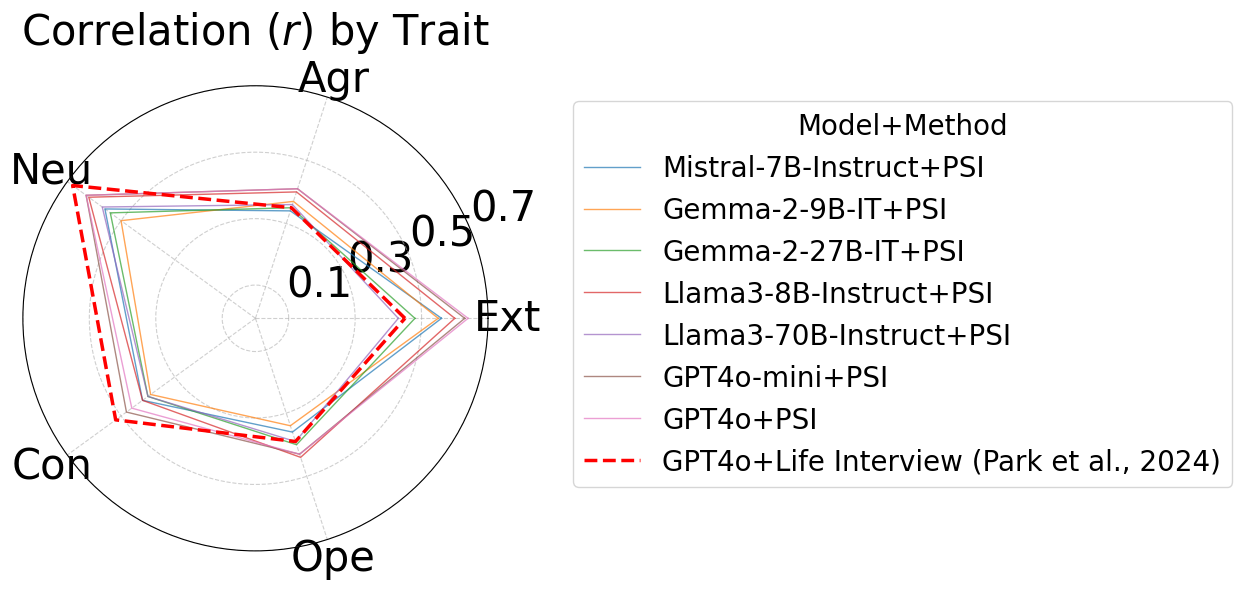

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Mistral-7B-Instruct+PSI",
    "Gemma-2-9B-IT+PSI",
    "Gemma-2-27B-IT+PSI",
    "Llama3-8B-Instruct+PSI",
    "Llama3-70B-Instruct+PSI",
    "GPT4o-mini+PSI",
    "GPT4o+PSI",
    "GPT4o+Life Interview (Park et al., 2024)"
]

traits = ["Ext", "Agr", "Neu", "Con", "Ope"]

mae_data = [
    [0.57, 0.66, 0.60, 0.57, 0.58],
    [0.62, 0.65, 0.79, 0.73, 0.95],
    [0.76, 0.50, 0.71, 0.65, 1.09],
    [0.62, 0.51, 0.61, 0.72, 0.93],
    [0.75, 0.56, 0.59, 0.66, 1.27],
    [0.60, 0.55, 0.63, 0.56, 0.81],
    [0.58, 0.53, 0.63, 0.59, 0.80],
    [0.72, 0.60, 0.75, 0.63, 0.62]
]

r_data = [
    [0.56, 0.34, 0.56, 0.42, 0.36],
    [0.55, 0.37, 0.50, 0.39, 0.34],
    [0.48, 0.35, 0.54, 0.40, 0.40],
    [0.60, 0.40, 0.62, 0.42, 0.44],
    [0.43, 0.36, 0.57, 0.40, 0.39],
    [0.63, 0.41, 0.63, 0.48, 0.43],
    [0.64, 0.41, 0.63, 0.46, 0.43],
    [0.45, 0.35, 0.68, 0.52, 0.39]
]

avg_mae = [round(np.mean(x), 2) for x in mae_data]
avg_r = [round(np.mean(x), 2) for x in r_data]

model_labels = [
    f"{model}"
    for model, mae, rval in zip(models, avg_mae, avg_r)
]

highlight_index = models.index("GPT4o+Life Interview (Park et al., 2024)")


def plot_correlation_radar(r_data, traits, highlight_index, model_labels):
    labels = np.array(traits)
    angles = np.linspace(0, 2 * np.pi, len(traits), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))
    title = "Correlation ($r$) by Trait"
    y_ticks = [0.1, 0.3, 0.5, 0.7]
    y_limits = (0, 0.7)

    for i, (label, scores) in enumerate(zip(model_labels, r_data)):
        values = scores + scores[:1]
        if i == highlight_index:
            ax.plot(angles, values, label=label, linewidth=2.5, linestyle='--', color='red')
            # ax.fill(angles, values, color='red', alpha=0.2)
        else:
            ax.plot(angles, values, label=label, linewidth=1, alpha=0.7)
            # ax.fill(angles, values, alpha=0.1)

    ax.set_title(title, size=30, pad=30)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=30)
    ax.set_yticks(y_ticks)
    ax.set_ylim(*y_limits)
    ax.tick_params(labelsize=30)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Legend on the right
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(0.85, 0.5),
        fontsize=20,
        title="Model+Method",
        title_fontsize=20,
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    return fig


fig = plot_correlation_radar(r_data, traits, highlight_index, model_labels)
plt.show()

# 保存为 PDF
fig.savefig("exp1_correlation.pdf", bbox_inches='tight')
